# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ishpree1t7/flyrank_work/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### Action queue interpretation

The queue ranks content using two observed signals: `days_since_last_update` and `impressions_90d`.

The highest-priority items combine relatively high content age with relatively low recent impressions. These are assigned the reason code `OLD_AND_LOW_IMPRESSIONS`.

The queue is a prioritization aid rather than a claim that these pages are definitely declining or that refreshing them will improve performance.

Observed reason-code counts in this run:

- OLD_AND_LOW_IMPRESSIONS: 941
- OLD_CONTENT: 8,150
- LOW_RECENT_IMPRESSIONS: 6,562
- LOWER_PRIORITY: 14,347

In [15]:
import os

REPO_PATH = "/content/flyrank_work"

if not os.path.exists(REPO_PATH):
    !git clone https://github.com/ishpree1t7/flyrank_work.git

print("Repo exists:", os.path.exists(REPO_PATH))
print("Repo contents:")
print(os.listdir(REPO_PATH))

Repo exists: True
Repo contents:
['DATA_USE.md', 'GUIDE.md', 'work', 'requirements.txt', 'outputs', 'submission', 'notebooks', '.gitignore', '.github', 'docs', '.git', 'AGENTS.md', 'CLAUDE.md', 'LICENSE', 'skills', 'README.md', 'SETUP.md', 'data', 'scripts']


In [16]:
import os
import pandas as pd
import numpy as np

# Paths
REPO_PATH = "/content/flyrank_work"
DATA_PATH = os.path.join(REPO_PATH, "data", "raw", "content_refresh_anonymized.csv")

# Load the anonymized working dataset
df = pd.read_csv(DATA_PATH)

# Recreate the Week-5 target
df["is_declining_label"] = (
    df["trend_direction"].astype(str).str.lower() == "down"
).astype(int)

# Week-5 validated features
FEATURES = [
    "days_since_last_update",
    "impressions_90d"
]

# Keep rows needed for the action queue
queue = df[
    [
        "content_id",
        "days_since_last_update",
        "impressions_90d",
        "is_declining_label"
    ]
].dropna().copy()

# Rank using the validated directional signals:
# older content gets higher refresh priority,
# while low recent impressions increase urgency.
queue["age_score"] = queue["days_since_last_update"].rank(pct=True)
queue["low_impression_score"] = (
    1 - queue["impressions_90d"].rank(pct=True)
)

# Combined decision-support priority score.
queue["priority_score"] = (
    0.5 * queue["age_score"]
    + 0.5 * queue["low_impression_score"]
)

# Reason codes
def reason_code(row):
    old = row["age_score"] >= 0.75
    low_impressions = row["low_impression_score"] >= 0.75

    if old and low_impressions:
        return "OLD_AND_LOW_IMPRESSIONS"
    elif old:
        return "OLD_CONTENT"
    elif low_impressions:
        return "LOW_RECENT_IMPRESSIONS"
    else:
        return "LOWER_PRIORITY"

queue["reason_code"] = queue.apply(reason_code, axis=1)

# Recommended human action
queue["recommended_action"] = np.select(
    [
        queue["reason_code"] == "OLD_AND_LOW_IMPRESSIONS",
        queue["reason_code"] == "OLD_CONTENT",
        queue["reason_code"] == "LOW_RECENT_IMPRESSIONS"
    ],
    [
        "Review for refresh",
        "Review freshness and refresh need",
        "Review performance and search intent"
    ],
    default="Monitor"
)

# Final ranking
queue = queue.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

queue["priority_rank"] = np.arange(1, len(queue) + 1)

print("Rows in action queue:", len(queue))
print("\nTop 10 recommended actions:")
display(
    queue[
        [
            "priority_rank",
            "content_id",
            "priority_score",
            "reason_code",
            "recommended_action"
        ]
    ].head(10)
)

print("\nReason-code distribution:")
display(queue["reason_code"].value_counts())

Rows in action queue: 30000

Top 10 recommended actions:


,priority_rank,content_id,priority_score,reason_code,recommended_action
0,1,content_3f3576c295f5,0.991017,OLD_AND_LOW_IMPRESSIONS,Review for refresh
1,2,content_8d56efff1e71,0.990975,OLD_AND_LOW_IMPRESSIONS,Review for refresh
2,3,content_84d12054c0c0,0.990625,OLD_AND_LOW_IMPRESSIONS,Review for refresh
3,4,content_84f8758f3d3e,0.990517,OLD_AND_LOW_IMPRESSIONS,Review for refresh
4,5,content_1f6f4bef3a32,0.989725,OLD_AND_LOW_IMPRESSIONS,Review for refresh
5,6,content_277fa742f704,0.989725,OLD_AND_LOW_IMPRESSIONS,Review for refresh
6,7,content_74961b456728,0.989725,OLD_AND_LOW_IMPRESSIONS,Review for refresh
7,8,content_1a6977ff1ef1,0.989725,OLD_AND_LOW_IMPRESSIONS,Review for refresh
8,9,content_e2fb3f55bed3,0.989725,OLD_AND_LOW_IMPRESSIONS,Review for refresh
9,10,content_e2181e471a9c,0.989725,OLD_AND_LOW_IMPRESSIONS,Review for refresh



Reason-code distribution:


,count
reason_code,
LOWER_PRIORITY,14347
OLD_CONTENT,8150
LOW_RECENT_IMPRESSIONS,6562
OLD_AND_LOW_IMPRESSIONS,941


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Practical use

A content strategist or editor can use the queue to decide which items to inspect first.

The intended action is human review. The ranking does not establish causality and does not prove that updating content will improve traffic, rankings, or conversions.

The approach is limited because it uses only two features and was developed from this dataset. It should be revalidated before being applied to a materially different portfolio or time period.

In [17]:
# Intended use and limits for the action playbook

intended_use = """
INTENDED USE

This playbook is a decision-support tool for content teams.

It ranks content for human review using two observed signals:
1. days_since_last_update
2. impressions_90d

Higher priority means the content shows a combination of greater age
and lower recent impressions in this dataset.

The queue is intended to help a reviewer decide which content to inspect
first. It is not a prediction that a page will definitely decline and
it does not prove that refreshing a page will improve performance.
"""

limits = """
LIMITS

- The ranking uses only two features and therefore gives a simplified view
  of content health.
- The reason codes are directional signals, not causal explanations.
- The observed relationships may not generalize to other datasets,
  time periods, or content portfolios.
- Low impressions can have many explanations that are not captured here.
- Content age alone does not mean that content needs to be refreshed.
- The queue should not be treated as an automatic publishing or deletion list.
- A human should review the underlying content and context before taking action.
"""

print(intended_use)
print(limits)

print("Queue size:", len(queue))
print("Highest priority score:", round(queue["priority_score"].max(), 3))
print("Lowest priority score:", round(queue["priority_score"].min(), 3))


INTENDED USE

This playbook is a decision-support tool for content teams.

It ranks content for human review using two observed signals:
1. days_since_last_update
2. impressions_90d

Higher priority means the content shows a combination of greater age
and lower recent impressions in this dataset.

The queue is intended to help a reviewer decide which content to inspect
first. It is not a prediction that a page will definitely decline and
it does not prove that refreshing a page will improve performance.


LIMITS

- The ranking uses only two features and therefore gives a simplified view
  of content health.
- The reason codes are directional signals, not causal explanations.
- The observed relationships may not generalize to other datasets,
  time periods, or content portfolios.
- Low impressions can have many explanations that are not captured here.
- Content age alone does not mean that content needs to be refreshed.
- The queue should not be treated as an automatic publishing or de

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human-in-the-loop requirement

A person must review the content and its context before any action is taken.

The system should not automatically publish, rewrite, delete, redirect, or make factual or editorial changes. It should also not infer search intent or guarantee the effect of a refresh from these two signals alone.

In [18]:
# Human review rules and no-go cases

human_review_rules = [
    "Check whether the content is actually outdated before recommending a refresh.",
    "Check whether the topic or search intent has changed since the content was published.",
    "Check the content for factual accuracy, completeness, and usefulness.",
    "Check whether low recent impressions could be explained by low search demand or another contextual factor.",
    "Check important business or editorial context that is not represented by the two model features.",
    "Treat the reason code as a prioritization signal, not as proof of the cause of decline.",
    "Record the review decision before making a content change."
]

no_go_cases = [
    "Do not automatically rewrite or publish content.",
    "Do not automatically delete or redirect content.",
    "Do not automatically change titles, claims, or factual statements.",
    "Do not automatically infer search intent from the two features alone.",
    "Do not automatically conclude that old content is poor content.",
    "Do not use the queue as evidence that a refresh will increase traffic or rankings.",
    "Do not make irreversible content decisions without human review."
]

print("HUMAN REVIEW RULES")
print("=" * 60)

for i, rule in enumerate(human_review_rules, 1):
    print(f"{i}. {rule}")

print("\nNO-GO CASES")
print("=" * 60)

for i, case in enumerate(no_go_cases, 1):
    print(f"{i}. {case}")

print("\nTotal human-review rules:", len(human_review_rules))
print("Total no-go cases:", len(no_go_cases))

HUMAN REVIEW RULES
1. Check whether the content is actually outdated before recommending a refresh.
2. Check whether the topic or search intent has changed since the content was published.
3. Check the content for factual accuracy, completeness, and usefulness.
4. Check whether low recent impressions could be explained by low search demand or another contextual factor.
5. Check important business or editorial context that is not represented by the two model features.
6. Treat the reason code as a prioritization signal, not as proof of the cause of decline.
7. Record the review decision before making a content change.

NO-GO CASES
1. Do not automatically rewrite or publish content.
2. Do not automatically delete or redirect content.
3. Do not automatically change titles, claims, or factual statements.
4. Do not automatically infer search intent from the two features alone.
5. Do not automatically conclude that old content is poor content.
6. Do not use the queue as evidence that a refre

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Monitoring approach

The recommendations should be treated as stale if measured ranking performance deteriorates, feature distributions shift, the content mix changes materially, the observed decline rate changes substantially, or the input fields become unreliable.

Monitoring should lead to investigation and revalidation. Retraining is a response to demonstrated performance or data changes, not an automatic calendar-based step.

In [19]:
# Monitoring and retraining triggers

monitoring_triggers = pd.DataFrame({
    "trigger": [
        "Precision@K falls materially",
        "Reason-code distribution changes substantially",
        "Feature distributions shift",
        "New data contains a different content mix",
        "Observed decline rate changes substantially",
        "Model inputs are no longer available or reliable"
    ],
    "what_to_check": [
        "Recalculate Precision@10, Precision@20, and Precision@50 on a recent labeled sample.",
        "Compare the current proportions of OLD_CONTENT, LOW_RECENT_IMPRESSIONS, and OLD_AND_LOW_IMPRESSIONS with the previous run.",
        "Compare recent distributions of days_since_last_update and impressions_90d with the validation data.",
        "Check whether the current portfolio differs materially from the data used to build and validate the approach.",
        "Compare the current observed is_declining_label rate with the previous evaluation period.",
        "Verify that the two features still have the same meaning, coverage, and measurement process."
    ],
    "recommended_response": [
        "Investigate the cause and consider recalibration or retraining.",
        "Investigate whether the underlying portfolio or data-generating process changed.",
        "Investigate data drift before relying on the queue.",
        "Revalidate the approach on the new content mix.",
        "Reassess model performance and calibration.",
        "Pause use of the queue until the inputs are validated."
    ]
})

display(monitoring_triggers)

print("\nRETRAIN / REVALIDATION POLICY")
print("=" * 60)
print(
    "Retraining should not happen simply because a fixed amount of time has passed. "
    "It should be considered when monitoring shows meaningful performance degradation, "
    "data drift, changed content mix, or unreliable inputs."
)

,trigger,what_to_check,recommended_response
0,Precision@K falls materially,"Recalculate Precision@10, Precision@20, and Pr...",Investigate the cause and consider recalibrati...
1,Reason-code distribution changes substantially,Compare the current proportions of OLD_CONTENT...,Investigate whether the underlying portfolio o...
2,Feature distributions shift,Compare recent distributions of days_since_las...,Investigate data drift before relying on the q...
3,New data contains a different content mix,Check whether the current portfolio differs ma...,Revalidate the approach on the new content mix.
4,Observed decline rate changes substantially,Compare the current observed is_declining_labe...,Reassess model performance and calibration.
5,Model inputs are no longer available or reliable,Verify that the two features still have the sa...,Pause use of the queue until the inputs are va...



RETRAIN / REVALIDATION POLICY
Retraining should not happen simply because a fixed amount of time has passed. It should be considered when monitoring shows meaningful performance degradation, data drift, changed content mix, or unreliable inputs.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

### Paper-ready exports

The ranked action queue is exported to:

`work/outputs/content_action_queue.csv`

The reusable priority-distribution figure is exported to:

`work/figures/action_priority_distribution.png`

The queue contains anonymized content identifiers and action-supporting fields only. It is generated by the notebook and should remain outside Git according to the repository's data-handling rules.

In [20]:
# Section 5 — Export the action queue and reusable figure

import os
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(REPO_PATH, "work", "outputs")
FIGURE_DIR = os.path.join(REPO_PATH, "work", "figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Figure directory:", FIGURE_DIR)

Output directory: /content/flyrank_work/work/outputs
Figure directory: /content/flyrank_work/work/figures


In [21]:
# Export the ranked action queue

QUEUE_PATH = os.path.join(
    OUTPUT_DIR,
    "content_action_queue.csv"
)

# Export only the fields needed for the action playbook
export_columns = [
    "priority_rank",
    "content_id",
    "days_since_last_update",
    "impressions_90d",
    "priority_score",
    "reason_code",
    "recommended_action"
]

queue_export = queue[export_columns].copy()

queue_export.to_csv(
    QUEUE_PATH,
    index=False
)

print("Queue exported to:")
print(QUEUE_PATH)

print("\nExported rows:", len(queue_export))
print("Exported columns:", list(queue_export.columns))

# Verify that the file can be read back
check = pd.read_csv(QUEUE_PATH)

print("\nVerification:")
print("File exists:", os.path.exists(QUEUE_PATH))
print("Rows read back:", len(check))
print("\nFirst 5 rows:")
display(check.head())

Queue exported to:
/content/flyrank_work/work/outputs/content_action_queue.csv

Exported rows: 30000
Exported columns: ['priority_rank', 'content_id', 'days_since_last_update', 'impressions_90d', 'priority_score', 'reason_code', 'recommended_action']

Verification:
File exists: True
Rows read back: 30000

First 5 rows:


,priority_rank,content_id,days_since_last_update,impressions_90d,priority_score,reason_code,recommended_action
0,1,content_3f3576c295f5,373,1,0.991017,OLD_AND_LOW_IMPRESSIONS,Review for refresh
1,2,content_8d56efff1e71,372,1,0.990975,OLD_AND_LOW_IMPRESSIONS,Review for refresh
2,3,content_84d12054c0c0,304,1,0.990625,OLD_AND_LOW_IMPRESSIONS,Review for refresh
3,4,content_84f8758f3d3e,301,1,0.990517,OLD_AND_LOW_IMPRESSIONS,Review for refresh
4,5,content_1f6f4bef3a32,211,1,0.989725,OLD_AND_LOW_IMPRESSIONS,Review for refresh


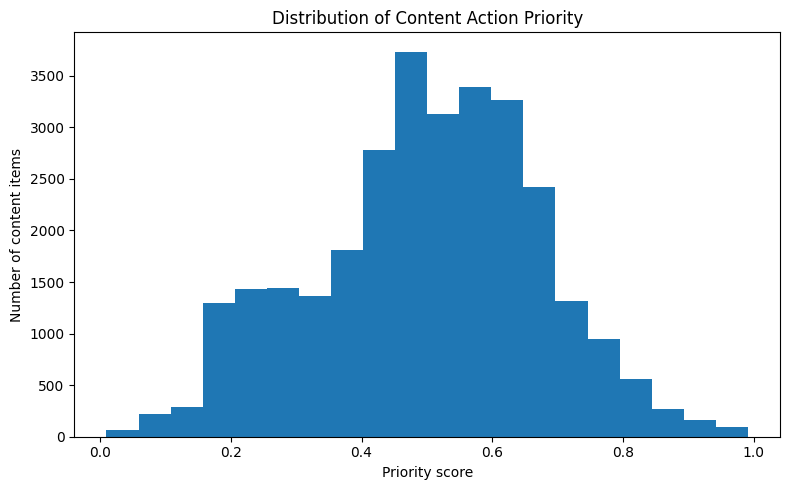

Figure saved to:
/content/flyrank_work/work/figures/action_priority_distribution.png
Figure exists: True


In [22]:
# Create a reusable figure showing the action-priority distribution

plt.figure(figsize=(8, 5))

plt.hist(
    queue["priority_score"],
    bins=20
)

plt.xlabel("Priority score")
plt.ylabel("Number of content items")
plt.title("Distribution of Content Action Priority")

plt.tight_layout()

FIGURE_PATH = os.path.join(
    FIGURE_DIR,
    "action_priority_distribution.png"
)

plt.savefig(
    FIGURE_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(FIGURE_PATH)

print("Figure exists:", os.path.exists(FIGURE_PATH))

In [23]:
# Final self-check

checks = {
    "Queue has 30,000 rows": len(queue_export) == 30000,
    "Queue is ranked": queue_export["priority_rank"].is_monotonic_increasing,
    "Queue CSV exists": os.path.exists(QUEUE_PATH),
    "Figure exists": os.path.exists(FIGURE_PATH),
    "No client_id in exported queue": "client_id" not in queue_export.columns,
    "No private query field in exported queue": "query" not in queue_export.columns,
}

print("SELF-CHECK")
print("=" * 60)

for check, result in checks.items():
    print(f"[{'PASS' if result else 'FAIL'}] {check}")

print("\nOverall result:", "PASS" if all(checks.values()) else "REVIEW NEEDED")

SELF-CHECK
[PASS] Queue has 30,000 rows
[PASS] Queue is ranked
[PASS] Queue CSV exists
[PASS] Figure exists
[PASS] No client_id in exported queue
[PASS] No private query field in exported queue

Overall result: PASS


## Self-check

- [x] Every section is filled with markdown explanation and supporting code.
- [x] The notebook runs top to bottom without errors.
- [x] The ranked queue contains 30,000 content items.
- [x] Reason codes and recommended actions are included.
- [x] Intended use and limitations are stated clearly.
- [x] Human-review rules and no-go cases are documented.
- [x] Monitoring and retrain/revalidation triggers are documented.
- [x] The ranked queue is exported to `work/outputs/content_action_queue.csv`.
- [x] A reusable figure is exported to `work/figures/action_priority_distribution.png`.
- [x] The exported queue does not contain `client_id` or private query fields.
- [x] Claims use careful language such as observed, directional, and decision-support.
- [x] No client names, private queries, or sensitive information are included.
- [x] The queue is treated as a human-review prioritization tool, not an automated decision system.
- [x] The notebook is ready to be committed under `work/notebooks/w07_action_playbook.ipynb`.

In [24]:
%cd /content/flyrank_work

!git status --short

/content/flyrank_work
?? work/figures/


In [25]:
%cd /content/flyrank_work

print("=== Git status ===")
!git status --short

print("\n=== Figure files ===")
!find work/figures -maxdepth 1 -type f -print

print("\n=== Output files ===")
!find work/outputs -maxdepth 1 -type f -print

print("\n=== Notebook ===")
!ls -lh work/notebooks/w07_action_playbook.ipynb

/content/flyrank_work
=== Git status ===
?? work/figures/

=== Figure files ===
work/figures/action_priority_distribution.png

=== Output files ===
work/outputs/content_action_queue.csv

=== Notebook ===
-rw-r--r-- 1 root root 2.8K Aug 28 10:47 work/notebooks/w07_action_playbook.ipynb


In [26]:
%cd /content/flyrank_work

import json

NOTEBOOK = "work/notebooks/w07_action_playbook.ipynb"

with open(NOTEBOOK, "r", encoding="utf-8") as f:
    nb = json.load(f)

print("Number of cells:", len(nb["cells"]))

for i, cell in enumerate(nb["cells"]):
    print(
        f"Cell {i}: {cell['cell_type']} | "
        f"source characters: {sum(len(x) for x in cell.get('source', []))}"
    )

/content/flyrank_work
Number of cells: 12
Cell 0: markdown | source characters: 486
Cell 1: markdown | source characters: 101
Cell 2: code | source characters: 0
Cell 3: markdown | source characters: 90
Cell 4: code | source characters: 0
Cell 5: markdown | source characters: 110
Cell 6: code | source characters: 0
Cell 7: markdown | source characters: 90
Cell 8: code | source characters: 0
Cell 9: markdown | source characters: 135
Cell 10: code | source characters: 0
Cell 11: markdown | source characters: 458
